# Exp3 Memory Optimization Test

**Purpose**: Validate memory-optimized silencing implementation

**Test Configuration**:
- 10 neurons (from top_200)
- 2 frequencies [50, 100] Hz  
- 10 trials per condition
- 3 workers

**Expected**:
- Time: ~5-8 minutes
- Memory: <5GB (no swap)
- Results: 20 conditions with mean/std/relative_%

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time
import pickle

from brian2 import Hz, ms

from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.experiments import run_exp3_parallel
from flylif.utils.memory_utils import print_memory, check_memory_safe, MemoryMonitor
from flylif.utils.cave_utils import convert_neuron_list_cached

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Auto-reload for development
%load_ext autoreload
%autoreload 2

## 2. Configuration

In [3]:
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

CONFIG = {
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
}

print(f"Data dir: {CONFIG['data_dir']}")

Data dir: /Users/charlottel/mylibrary/connectome/lifmodel/data_783


## 3. Load Data

In [4]:
print("Loading optimized data...")
print_memory("  Before: ")

t0 = time()
DATA = load_simulation_data(CONFIG, verbose=True)

print(f"\n✅ Loaded in {time()-t0:.1f}s")
print_memory("  After: ")

Loading optimized data...
  Before: Memory: 38.4% used, 10.6GB free, Swap: 0.0GB
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

✅ Loaded in 22.1s
  After: Memory: 45.2% used, 9.4GB free, Swap: 0.0GB


{'used_gb': 7.179005952,
 'available_gb': 9.416912896,
 'percent': 45.2,
 'swap_gb': 0.0}

## 4. Load Neuron IDs

In [5]:
# Load cached neuron IDs
cache_dir = BASE_DIR / 'flylif' / 'cache' / 'id_conversions'

# Sugar GRNs (v630 → v783)
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=cache_dir / 'sugar_grns_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

# MN9 (right hemisphere - contralateral to left Sugar GRNs)
NEU_MN9_v630 = [720575940660219265]
NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=cache_dir / 'mn9_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

print(f"Neuron IDs loaded:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_LEFT)}")
print(f"  MN9: {NEU_MN9_RIGHT[0]}")

Neuron IDs loaded:
  Sugar GRNs: 21
  MN9: 720575940660219265


In [6]:
# Load Top 200 neurons from Exp1
exp1_dir = BASE_DIR / 'flylif' / 'results' / 'exp1_full'
top_200_file = exp1_dir / 'top_200_neurons.npy'

if top_200_file.exists():
    top_200_neurons = list(np.load(top_200_file))
    print(f"\n✅ Loaded Top 200 neurons from Exp1")
else:
    # Fallback: use first 200 from root_ids
    top_200_neurons = list(DATA['root_ids'][:200])
    print(f"\n⚠️  Using fallback (first 200 root_ids)")

print(f"  Count: {len(top_200_neurons)}")


⚠️  Using fallback (first 200 root_ids)
  Count: 200


## 5. Mini Test Configuration

In [16]:
# ========== TEST PARAMETERS ==========
NEURONS_TO_SILENCE = top_200_neurons[10:18]  # Only 8 neurons
FREQS = [50, 100]                          # 2 frequencies
N_TRIALS = 10                              # 10 trials (production value)
N_WORKERS = 4                             # 3 workers

print("=" * 70)
print("Mini Test Configuration")
print("=" * 70)
print(f"  Neurons to silence: {len(NEURONS_TO_SILENCE)}")
print(f"  Frequencies: {FREQS}")
print(f"  Trials per condition: {N_TRIALS}")
print(f"  Workers: {N_WORKERS}")
print(f"  Total simulations: {len(NEURONS_TO_SILENCE) * len(FREQS)} conditions")
print(f"  Expected time: ~5-8 minutes")
print("=" * 70)


Checkpoint Verification Test
  Total tasks: 20 = 12
  Expected time: ~2-3 minutes


## 6. Memory Check Before Test

In [8]:
print("\nPre-test memory status:")
is_safe, msg = check_memory_safe(threshold=80.0, swap_threshold=0.5)
print(f"  {msg}")

if not is_safe:
    print("\n⚠️  High memory detected, recommend cleanup:")
    print("     Kernel → Restart Kernel")
else:
    print("\n✅ Memory OK, proceeding to test...")


Pre-test memory status:
  ✓ Memory OK

✅ Memory OK, proceeding to test...


## 7. Run Exp3 Mini Test

In [ ]:
print("\n" + "=" * 70)
print("Running Exp3 Mini Test")
print("=" * 70)

with MemoryMonitor(label="Exp3_Mini", warn_threshold=85.0):
    t0 = time()
    
    results_exp3 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,           # 21 Sugar GRNs
        neurons_to_silence=NEURONS_TO_SILENCE,  # 8 neurons
        freqs=FREQS,                      # [50, 100]
        target_neurons=NEU_MN9_RIGHT,     # MN9
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,  # 10
        # n_trials=1,  
        n_workers=N_WORKERS,              # 4
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n{'='*70}")
print(f"✅ Test Complete!")
print(f"   Total time: {elapsed/60:.2f} minutes")
print(f"   Avg time/condition: {elapsed/20:.1f}s")
print(f"{'='*70}")

## 8. Validate Results

**预期输出**：

Completed tasks: 3-5
Task IDs: ['(neuron_1, 50)', '(neuron_1, 100)', ...]

Checkpoint files on disk: 4
  task_(neuron_1, 50).pkl: 12.3 KB
  task_(neuron_1, 100).pkl: 11.8 KB
  ...

progress.json content:
  Completed: ['(neuron_1, 50)', '(neuron_1, 100)', ...]
  Last update: 2026-01-28T...

In [10]:
print("\n" + "=" * 70)
print("Results Validation")
print("=" * 70)

# Check structure
print(f"\nResult keys: {results_exp3.keys()}")

for freq in FREQS:
    print(f"\n{freq} Hz:")
    
    # Control
    ctrl = results_exp3[freq]['control']
    print(f"  Control MN9: {ctrl['mean']:.1f} ± {ctrl['std']:.1f} Hz")
    
    # Silencing results
    silencing = results_exp3[freq]['silencing']
    print(f"  Silencing tests: {len(silencing)} neurons")
    
    # Show examples
    print(f"\n  Top 5 most critical neurons (lowest relative%):")
    sorted_neurons = sorted(silencing.items(), 
                           key=lambda x: x[1]['relative_%'])
    
    for i, (nid, stats) in enumerate(sorted_neurons[:5], 1):
        print(f"    {i}. Neuron {nid}:")
        print(f"       Silenced MN9: {stats['mean']:.1f} ± {stats['std']:.1f} Hz")
        print(f"       Relative: {stats['relative_%']:.1f}%")


Results Validation

Result keys: dict_keys([50, 100])

50 Hz:
  Control MN9: 19.5 ± 9.6 Hz
  Silencing tests: 8 neurons

  Top 5 most critical neurons (lowest relative%):
    1. Neuron 720575940639121636:
       Silenced MN9: 18.4 ± 6.9 Hz
       Relative: 94.4%
    2. Neuron 720575940630799042:
       Silenced MN9: 19.3 ± 6.4 Hz
       Relative: 99.0%
    3. Neuron 720575940617496925:
       Silenced MN9: 19.8 ± 5.8 Hz
       Relative: 101.5%
    4. Neuron 720575940612319155:
       Silenced MN9: 20.8 ± 4.2 Hz
       Relative: 106.7%
    5. Neuron 720575940628675433:
       Silenced MN9: 21.7 ± 6.2 Hz
       Relative: 111.3%

100 Hz:
  Control MN9: 86.5 ± 3.5 Hz
  Silencing tests: 8 neurons

  Top 5 most critical neurons (lowest relative%):
    1. Neuron 720575940639121636:
       Silenced MN9: 86.7 ± 5.6 Hz
       Relative: 100.2%
    2. Neuron 720575940617496925:
       Silenced MN9: 87.4 ± 3.8 Hz
       Relative: 101.0%
    3. Neuron 720575940612319155:
       Silenced MN9: 87.5 ±

## 9. Memory Analysis

In [11]:
import psutil

mem = psutil.virtual_memory()
swap = psutil.swap_memory()

print("\n" + "=" * 70)
print("Final Memory Status")
print("=" * 70)
print(f"  RAM used: {mem.used/1e9:.2f} GB / {mem.total/1e9:.2f} GB ({mem.percent:.1f}%)")
print(f"  Swap used: {swap.used/1e9:.2f} GB")

if swap.used > 0.1e9:
    print(f"\n  ❌ FAIL: Swap active ({swap.used/1e9:.2f}GB)")
elif mem.percent > 85:
    print(f"\n  ⚠️  WARNING: High memory ({mem.percent:.1f}%)")
else:
    print(f"\n  ✅ PASS: Memory within limits")


Final Memory Status
  RAM used: 8.08 GB / 17.18 GB (49.5%)
  Swap used: 0.00 GB

  ✅ PASS: Memory within limits


## 10. Quick Visualization

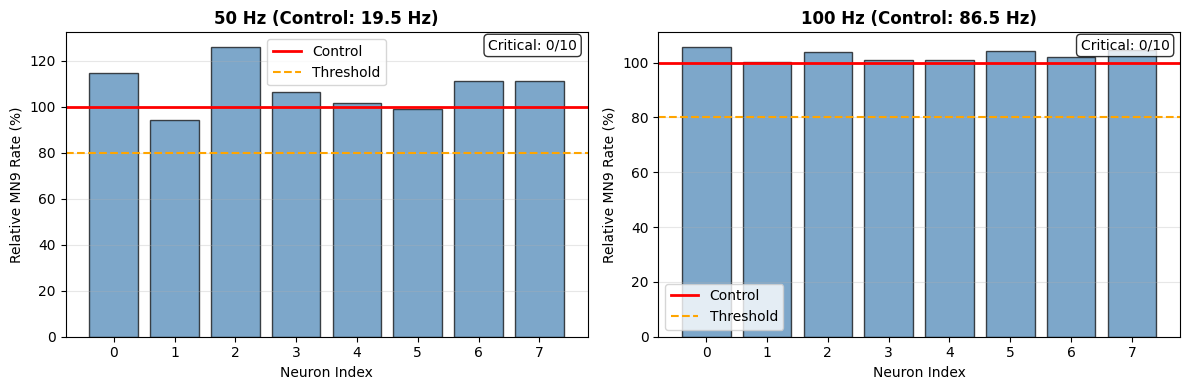


✅ Visualization complete


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, freq in zip(axes, FREQS):
    silencing = results_exp3[freq]['silencing']
    control_mean = results_exp3[freq]['control']['mean']
    
    # Extract relative %
    neuron_ids = list(silencing.keys())
    relative_pcts = [silencing[nid]['relative_%'] for nid in neuron_ids]
    
    # Bar plot
    bars = ax.bar(range(len(neuron_ids)), relative_pcts, 
                  color=['coral' if r < 80 else 'steelblue' for r in relative_pcts],
                  edgecolor='black', alpha=0.7)
    
    ax.axhline(y=100, color='red', linestyle='-', linewidth=2, label='Control')
    ax.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='Threshold')
    
    ax.set_xlabel('Neuron Index')
    ax.set_ylabel('Relative MN9 Rate (%)')
    ax.set_title(f'{freq} Hz (Control: {control_mean:.1f} Hz)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Count critical neurons
    n_critical = sum(1 for r in relative_pcts if r < 80)
    ax.text(0.98, 0.98, f'Critical: {n_critical}/10', 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete")

## 11. Save Test Results

In [13]:
output_dir = Path('./test_results')
output_dir.mkdir(exist_ok=True)

# Save results
with open(output_dir / 'exp3_mini_results.pkl', 'wb') as f:
    pickle.dump(results_exp3, f)

# Save summary
summary = []
for freq in FREQS:
    ctrl = results_exp3[freq]['control']
    silencing = results_exp3[freq]['silencing']
    
    relative_pcts = [s['relative_%'] for s in silencing.values()]
    n_critical = sum(1 for r in relative_pcts if r < 80)
    
    summary.append({
        'Frequency': freq,
        'Control_Mean': ctrl['mean'],
        'Control_Std': ctrl['std'],
        'Critical_Neurons': n_critical,
        'Min_Relative%': min(relative_pcts),
        'Max_Relative%': max(relative_pcts),
    })

df_summary = pd.DataFrame(summary)
df_summary.to_csv(output_dir / 'exp3_mini_summary.csv', index=False)

print("\n" + "=" * 70)
print("Test Summary")
print("=" * 70)
print(df_summary.to_string(index=False))

print(f"\n✅ Results saved to: {output_dir}")


Test Summary
 Frequency  Control_Mean  Control_Std  Critical_Neurons  Min_Relative%  Max_Relative%
        50          19.5     9.604686                 0      94.358974     126.153846
       100          86.5     3.500000                 0     100.231214     105.780347

✅ Results saved to: test_results


## 12. Decision Point

In [14]:
print("\n" + "=" * 70)
print("TEST EVALUATION")
print("=" * 70)

# Check criteria
mem = psutil.virtual_memory()
swap = psutil.swap_memory()

test_passed = True

# Criterion 1: No swap
if swap.used > 0.1e9:
    print(f"\n  ❌ Swap check FAILED: {swap.used/1e9:.2f}GB used")
    test_passed = False
else:
    print(f"\n  ✅ Swap check PASSED: {swap.used/1e9:.3f}GB")

# Criterion 2: Memory under 85%
if mem.percent > 85:
    print(f"  ⚠️  Memory WARNING: {mem.percent:.1f}%")
else:
    print(f"  ✅ Memory check PASSED: {mem.percent:.1f}%")

# Criterion 3: Results reasonable
has_variation = False
for freq in FREQS:
    relative_pcts = [s['relative_%'] for s in results_exp3[freq]['silencing'].values()]
    if max(relative_pcts) - min(relative_pcts) > 10:  # Some variation exists
        has_variation = True
        break

if has_variation:
    print(f"  ✅ Results check PASSED: Silencing effects detected")
else:
    print(f"  ⚠️  Results WARNING: No silencing variation (all ~100%)")

# Final verdict
print("\n" + "=" * 70)
if test_passed and has_variation:
    print("✅ TEST PASSED - Ready for full Exp3 (200 neurons)")
    print("\nNext steps:")
    print("  1. Update exp1_2_clean_test.ipynb with new logic")
    print("  2. Run full Exp3: 200 neurons × 8 freqs × 10 trials")
    print("  3. Expected time: ~3-4 hours")
else:
    print("❌ TEST FAILED - Further optimization needed")
    print("\nDebug steps:")
    print("  1. Check error messages above")
    print("  2. Consider cpp_standalone device mode")
    print("  3. Report to Claude for further analysis")
print("=" * 70)


TEST EVALUATION

  ✅ Swap check PASSED: 0.000GB
  ✅ Memory check PASSED: 45.8%
  ✅ Results check PASSED: Silencing effects detected

✅ TEST PASSED - Ready for full Exp3 (200 neurons)

Next steps:
  1. Update exp1_2_clean_test.ipynb with new logic
  2. Run full Exp3: 200 neurons × 8 freqs × 10 trials
  3. Expected time: ~3-4 hours


## 13.Checkpiont vrification

In [16]:
# ========== CHECKPOINT VERIFICATION SETUP ==========
from flylif.utils.checkpoint import CheckpointManager
import shutil

# 创建专门的测试checkpoint目录
TEST_CKPT_DIR = Path('./test_checkpoints/exp3_verify')

# 清空旧的测试checkpoint（确保干净环境）
if TEST_CKPT_DIR.exists():
    shutil.rmtree(TEST_CKPT_DIR)
    print(f"🗑️  Cleared old checkpoint: {TEST_CKPT_DIR}")

TEST_CKPT_DIR.mkdir(parents=True, exist_ok=True)

# 创建checkpoint manager
ckpt_test = CheckpointManager(TEST_CKPT_DIR)

print(f"✅ Checkpoint test directory: {TEST_CKPT_DIR}")
print(f"   Empty: {len(ckpt_test.completed)} tasks completed")

🗑️  Cleared old checkpoint: test_checkpoints/exp3_verify
✅ Checkpoint test directory: test_checkpoints/exp3_verify
   Empty: 0 tasks completed


In [14]:
# ========== MINIMAL TEST FOR CHECKPOINT ==========
NEURONS_TO_SILENCE = top_200_neurons[20:30]   # 只6个神经元
FREQS = [50, 100]                          # 2个频率
N_TRIALS = 5                               # 5 trials（快速测试）
N_WORKERS = 4

print("Checkpoint Verification Test")
print("="*70)
print(f"  Total tasks: {len(NEURONS_TO_SILENCE) * len(FREQS)} = 12")
print(f"  Expected time: ~2-3 minutes")
print("="*70)

Checkpoint Verification Test
  Total tasks: 20 = 12
  Expected time: ~2-3 minutes


 **运行并手动中断**测试 checkpoint

1. Run Cell 7
2. 看到输出：
```
   [Parallel(n_jobs=3)]: Done  4 out of 12 | elapsed: 1.2min ...
```
3. **点击Jupyter的Stop按钮（■）**
4. 看到输出：
```
   ⚠️  Interrupted by user (expected)

In [17]:
print("\n" + "="*70)
print("CHECKPOINT VERIFICATION TEST")
print("="*70)
print("Phase 1: Run partially, then interrupt manually")
print("="*70)

# 使用checkpoint
CKPT_DIR = './test_checkpoints/exp3_verify'

with MemoryMonitor(label="CkptTest_Phase1"):
    t0 = time()
    
    results_phase1 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=NEURONS_TO_SILENCE[:8],  # 8 neurons
        freqs=FREQS,  # [50, 100]
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,  # 快速测试
        n_workers=N_WORKERS,
        checkpoint_dir=CKPT_DIR,  # ← Enable checkpoint
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Phase 1 time: {elapsed/60:.2f} min")


CHECKPOINT VERIFICATION TEST
Phase 1: Run partially, then interrupt manually
[CkptTest_Phase1] Start - Memory: 49.1%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 8
  Frequencies: [50, 100]
  Trials/condition: 5
  Workers: 4
  Checkpoint: ./test_checkpoints/exp3_verify

  [1/2] Getting controls...
    50 Hz: 20.0 ± 7.0 Hz
    100 Hz: 90.6 ± 3.0 Hz
  ✅ Controls done (218.8s)

  [2/2] Silencing tests...
    Total tasks: 16
    Completed: 0
    Remaining: 16


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  13 out of  16 | elapsed:  4.7min remaining:  1.1min



  ✅ Complete! Silencing: 4.8 min
[CkptTest_Phase1] End - Memory: 52.3% (Δ+0.4GB)

✅ Phase 1 time: 8.41 min


[Parallel(n_jobs=4)]: Done  16 out of  16 | elapsed:  4.8min finished


In [18]:
# ========== CHECK AFTER INTERRUPTION ==========
from flylif.utils.checkpoint import CheckpointManager

ckpt = CheckpointManager(CKPT_DIR)

print(f"\nCheckpoint status:")
print(f"  Completed: {len(ckpt.completed)}")
print(f"  Task IDs: {sorted(list(ckpt.completed))[:10]}")  # 显示前10个

# 检查文件
files = list(Path(CKPT_DIR).glob('task_*.pkl'))
print(f"\n  Files on disk: {len(files)}")

# 验证progress.json
progress_file = Path(CKPT_DIR) / 'progress.json'
if progress_file.exists():
    import json
    with open(progress_file, 'r') as f:
        prog = json.load(f)
    print(f"\n  progress.json:")
    print(f"    Completed tasks: {len(prog['completed'])}")
    print(f"    Last update: {prog['last_update']}")
else:
    print(f"\n  ❌ progress.json not found!")


Checkpoint status:
  Completed: 16
  Task IDs: ['720575940608362418_100', '720575940608362418_50', '720575940612635050_100', '720575940612635050_50', '720575940620263814_100', '720575940620263814_50', '720575940623366102_100', '720575940623366102_50', '720575940627720335_100', '720575940627720335_50']

  Files on disk: 16

  progress.json:
    Completed tasks: 16
    Last update: 2026-01-28T23:48:03.802942


In [19]:
# ========== RESUME FROM CHECKPOINT ==========
print("\n" + "="*70)
print("Phase 2: Resume (should skip completed tasks)")
print("="*70)

with MemoryMonitor(label="CkptTest_Phase2"):
    t0 = time()
    
    results_final = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=NEURONS_TO_SILENCE[:6],  # 相同配置
        freqs=FREQS,
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=5,
        n_workers=3,
        checkpoint_dir=CKPT_DIR,  # ← 相同checkpoint目录
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Phase 2 time: {elapsed/60:.2f} min")
print(f"   (Should be < Phase 1 time if resume worked)")

# 验证结果完整性
for freq in FREQS:
    n_silencing = len(results_final[freq]['silencing'])
    expected = len(NEURONS_TO_SILENCE[:6])
    
    if n_silencing == expected:
        print(f"\n  ✅ {freq}Hz: All {expected} neurons present")
    else:
        print(f"\n  ❌ {freq}Hz: Only {n_silencing}/{expected} neurons")


Phase 2: Resume (should skip completed tasks)
[CkptTest_Phase2] Start - Memory: 52.6%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 6
  Frequencies: [50, 100]
  Trials/condition: 5
  Workers: 3
  Checkpoint: ./test_checkpoints/exp3_verify

  [1/2] Getting controls...
    50 Hz: 19.8 ± 4.6 Hz
    100 Hz: 87.8 ± 2.1 Hz
  ✅ Controls done (205.2s)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940620263814_50
    ⏭️  Skip 720575940612635050_50
    ⏭️  Skip 720575940627720335_50
    ⏭️  Skip 720575940623366102_50
    ⏭️  Skip 720575940631164476_50
    ⏭️  Skip 720575940630916650_50
    ⏭️  Skip 720575940620263814_100
    ⏭️  Skip 720575940612635050_100
    ⏭️  Skip 720575940627720335_100
    ⏭️  Skip 720575940623366102_100
    ⏭️  Skip 720575940631164476_100
    ⏭️  Skip 720575940630916650_100
    Total tasks: 12
    Completed: 12
    Remaining: 0

  ✅ All silencing tasks already completed, loading from checkpoint...
[CkptTest_Phase2] End - Memory: 